In [35]:
import numpy as np
import matplotlib.pyplot as plt

In [36]:
def least_square_fitting(X, Y,X_axis,Y_axis,plot,t):
    # TABLE DATA
    Σx2 = 0
    Σy = 0
    Σxy = 0
    Σx = 0
    count = 0
    Σxylist = []
    Σx2list = []
    Slno = [ ]

    for i in range(len(X)):
        Σx2 += X[i]**2
        Σx2list.append(round(X[i]**2,4))
        Σy += Y[i]
        Σxy += X[i]*Y[i]
        Σxylist.append(round(X[i]*Y[i],4))
        Σx += X[i]
        count += 1
        Slno.append(count)

    # Finding slope and intercept
    fit = np.polyfit(X,Y,1)
    A = fit[0]
    B = fit[1]
    def f(x):
      return A*x + B
    # Error analysis
    error_sum = 0
    for i in range(len(X)):
        error_sum += (Y[i] - f(X[i]))**2
    error_y = (error_sum/ (len(X) - 2))**0.5
    delta = len(X)*Σx2 - Σx**2
    error_slope = error_y * (len(X)/delta)**0.5
    error_intercept = error_y * (Σx2/delta)**0.5

    if plot==True:
        #GRAPH PLOT
        plt.xlabel(X_axis)
        plt.ylabel(Y_axis)
        plt.title(X_axis + " vs " + Y_axis + t)
        plt.grid()
        plt.scatter(X,Y,label='Data Points',s=20,c='red')
        fit = np.polyfit(X,Y,1)
        x_fit = np.linspace(min(X),max(X),1000)
        y_fit = fit[1]+fit[0]*x_fit
        plt.plot(x_fit,y_fit,'--',c='darkblue', label = f'Least-square fit line : y = ({round(A,4)}±{round(error_slope,4)})x + ({round(B,4)}±{round(error_intercept,4)})')
        plt.legend()
        plt.show()
       

In [37]:
theta = [0,30,45,60,90,120] # in deg
t = [100,500,500,500,500,500] # in sec
I_al = [151.10,1.726 ,1.320 ,0.868 ,0.680 ,0.926 ] # count rate
I_brass = [80.92, 3.058, 2.162, 1.400, 1.016, 1.372] # count rate
def dsigmadtheta(m):
     r0 = 2.818e-15 
     g = 662/511
     rad_m = np.radians(m)
     cos_m = np.cos(rad_m)
     alpha = g
     term = 1 + alpha * (1 - cos_m)
     numerator = (1 + cos_m**2) / 2
     denom = term**2
     extra = alpha**2 * (1 - cos_m)**2 / ((1 + cos_m**2) * term)
     a = r0**2 * numerator / denom * (1 + extra)
     return round(a*1e30,4)

def calib_fac(I_al,dsdt):
    C = 0
    for i in range(len(I_al)):
        C += I_al[i]/dsdt[i]
    C = C/len(I_al)
    return round(C*1e-30,2)

def calib_error(I_al,dsdt,t):
    term = 0
    for i in range(len(I_al)):
        term += I_al[i]/(dsdt[i]**2*t[i])
    term = np.sqrt(term)/len(I_al)
    return term



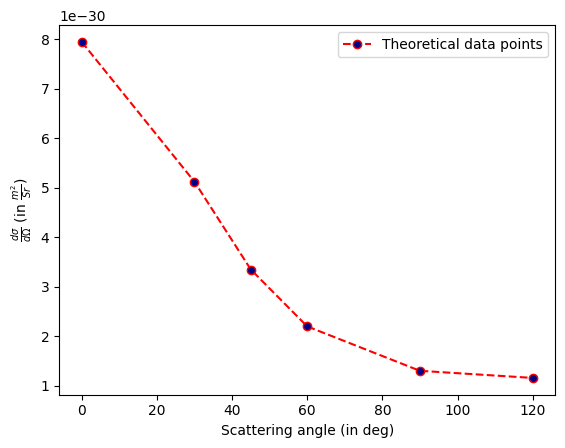

for al 3.58e+30
for al error 2.7314981813259074e+28
for brass 2.34e+30
for brass error 2.189579362739264e+28


In [38]:
dsdt = [dsigmadtheta(m)*1e-30 for m in theta]
# print(dsdt)
plt.plot(theta,dsdt,marker='o',mfc='darkblue',linestyle='--',color='r',label='Theoretical data points')
plt.xlabel('Scattering angle (in deg)')
plt.ylabel(r'$\frac{d\sigma}{d\Omega}$ (in $\frac{m^2}{Sr}$)')
plt.legend()
plt.show()

# calibration factor
print('for al',calib_fac(I_al,dsdt)*1e30)
print('for al error',calib_error(I_al,dsdt,t))

print('for brass',calib_fac(I_brass,dsdt)*1e30)
print('for brass error',calib_error(I_brass,dsdt,t))


[-0.0001, 0.0034, 0.008, 0.0125, 0.0253, 0.0392]
[-0.0001, 0.0031, 0.0079, 0.0122, 0.0245, 0.0375]


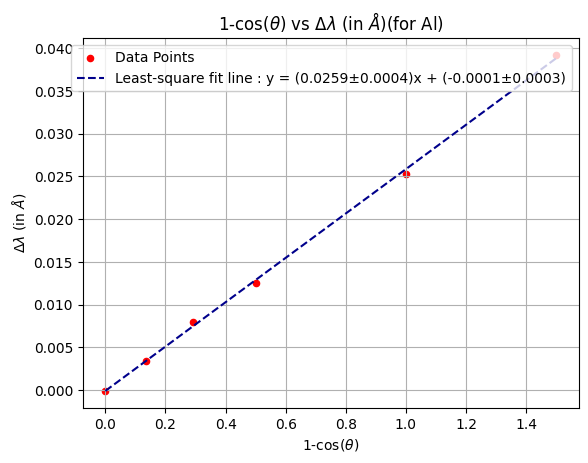

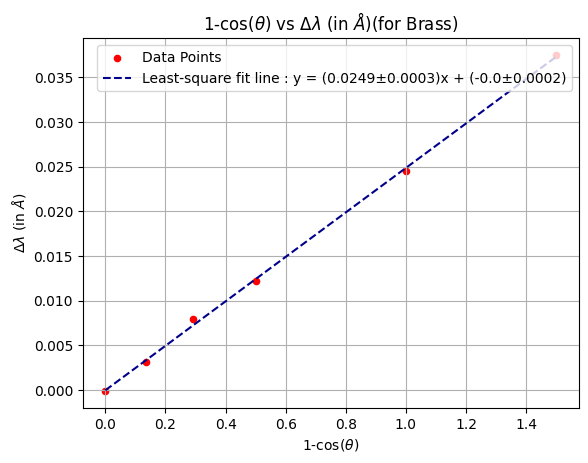

In [42]:
E_al = [665.8,560.7,465.2,397.5,281.5,214.2] # in KeV
E_brass = [665.1,568.7,465.8,400.9,287.2,220.7] # in KeV
ctheta = [1 -np.cos(np.radians(j)) for j in theta]
Lambda = 12.398/661.66  # 661.66 KeV
l_al = [round(12.398 / e, 4) for e in E_al] # in angstrom
l_brass = [round(12.398 / e, 4) for e in E_brass] # in angstrom
dlambda_al = [round(l_al[i]-Lambda,4) for i in range(len(l_al))] # change in lambda
dlambda_brass = [round(l_brass[i]-Lambda,4) for i in range(len(l_brass))]
print(dlambda_al)
print(dlambda_brass)

least_square_fitting(ctheta,dlambda_al,r'1-$\cos(\theta)$',r'$\Delta\lambda$ (in $\AA$)',True,'(for Al)')
least_square_fitting(ctheta,dlambda_brass,r'1-$\cos(\theta)$',r'$\Delta\lambda$ (in $\AA$)',True, '(for Brass)')

# print("Wavelengths for Al:", l_al)
# print("Wavelengths for Brass:", l_brass)